<a href="https://colab.research.google.com/github/korzhimanov/dsp-seminars/blob/main/seminars/5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №5
## Основные характеристики цифровых фильтров

## Импорт библиотек

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import savgol_filter, savgol_coeffs, group_delay
import ipywidgets as widgets
from IPython.display import display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

# Вспомогательная функция для построения частотных характеристик
def plot_filter_response(b, a, fs=1000, title=''):
    """Строит АЧХ (линейный и дБ), ФЧХ и групповую задержку фильтра"""
    w, H = signal.freqz(b, a, fs=fs)
    mag_dB = 20*np.log10(np.abs(H) + 1e-12)
    phase = np.unwrap(np.angle(H))
    w_gd, gd = signal.group_delay((b, a), fs=fs)

    plt.figure(figsize=(12,10))
    plt.subplot(4,1,1)
    plt.semilogy(w, np.abs(H))
    plt.title(f'АЧХ (линейный масштаб) – {title}')
    plt.grid()
    plt.subplot(4,1,2)
    plt.plot(w, mag_dB)
    plt.title('АЧХ (дБ)')
    plt.ylabel('|H| (дБ)')
    plt.grid()
    plt.subplot(4,1,3)
    plt.plot(w, phase)
    plt.title('ФЧХ')
    plt.ylabel('Фаза (рад)')
    plt.grid()
    plt.subplot(4,1,4)
    plt.plot(w_gd, gd)
    plt.title('Групповая задержка')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Задержка (отсчёты)')
    plt.grid()
    plt.tight_layout()
    plt.show()


## Часть 1. КИХ-фильтр: скользящее среднее

**Скользящее среднее** – простейший КИХ-фильтр. Его коэффициенты: `b_k = 1/M` для `k = 0,...,M-1`. Фильтр имеет линейную фазу.

### Задание 1.1. Импульсная и переходная характеристики

Для длины окна `M = 5`:
1. Сформируйте массив коэффициентов `b` (нормированный).
2. Создайте тестовые сигналы: единичный импульс (длиной 20 отсчётов) и единичный скачок (длиной 50 отсчётов).
3. Примените фильтр с помощью `signal.lfilter(b, a, x)`, где `a = [1]`.
4. Постройте импульсную и переходную характеристики.


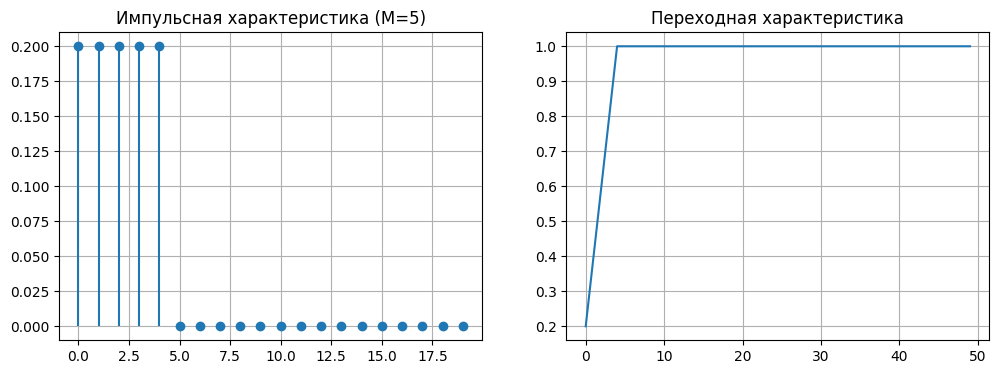

In [5]:
# Ваш код здесь
M = 5
b = np.ones(M) / M
a = [1]

# Импульс
impulse = np.zeros(20)
impulse[0] = 1
h = signal.lfilter(b, a, impulse)

# Скачок
step = np.ones(50)
s = signal.lfilter(b, a, step)

# Построение
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.stem(h, basefmt=" ")
plt.title(f'Импульсная характеристика (M={M})')
plt.grid()
plt.subplot(1,2,2)
plt.plot(s)
plt.title('Переходная характеристика')
plt.grid()
plt.show()


**Вопрос:** Почему импульсная характеристика имеет конечную длину, а переходная выходит на постоянный уровень?


**Ответ:**
Импульсная характеристика конечная, потому что скользящее среднее — это КИХ-фильтр: он использует только конечное число отсчётов, равное длине окна M. После этого вклад импульса исчезает. Переходная характеристика выходит на постоянный уровень, потому что при постоянном входном сигнале среднее значение тоже становится постоянным

### Задание 1.2. АЧХ и ФЧХ

Используя функцию `plot_filter_response`, постройте характеристики для скользящего среднего с длинами окон `M = 5`, `M = 10`, `M = 20`.


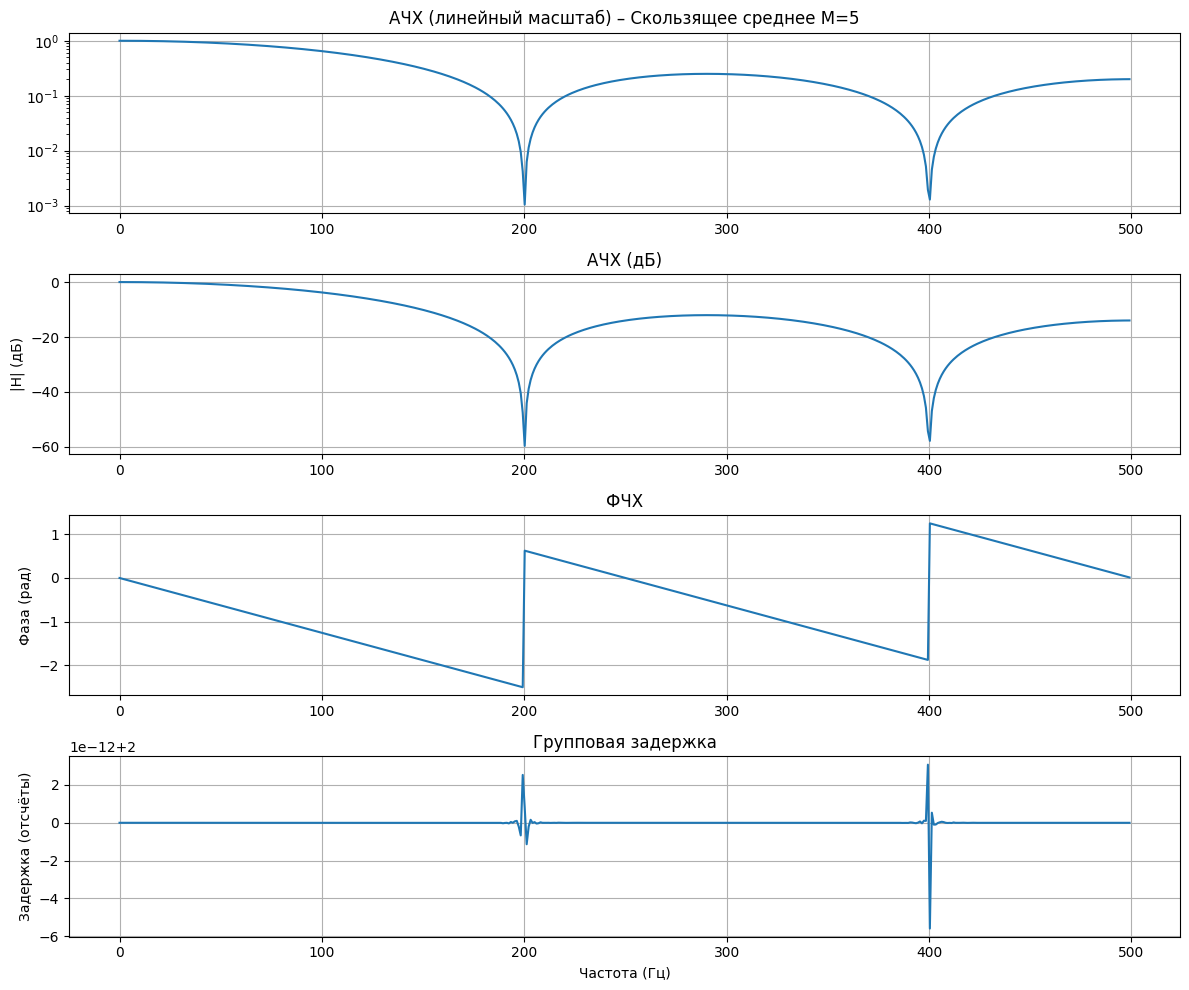

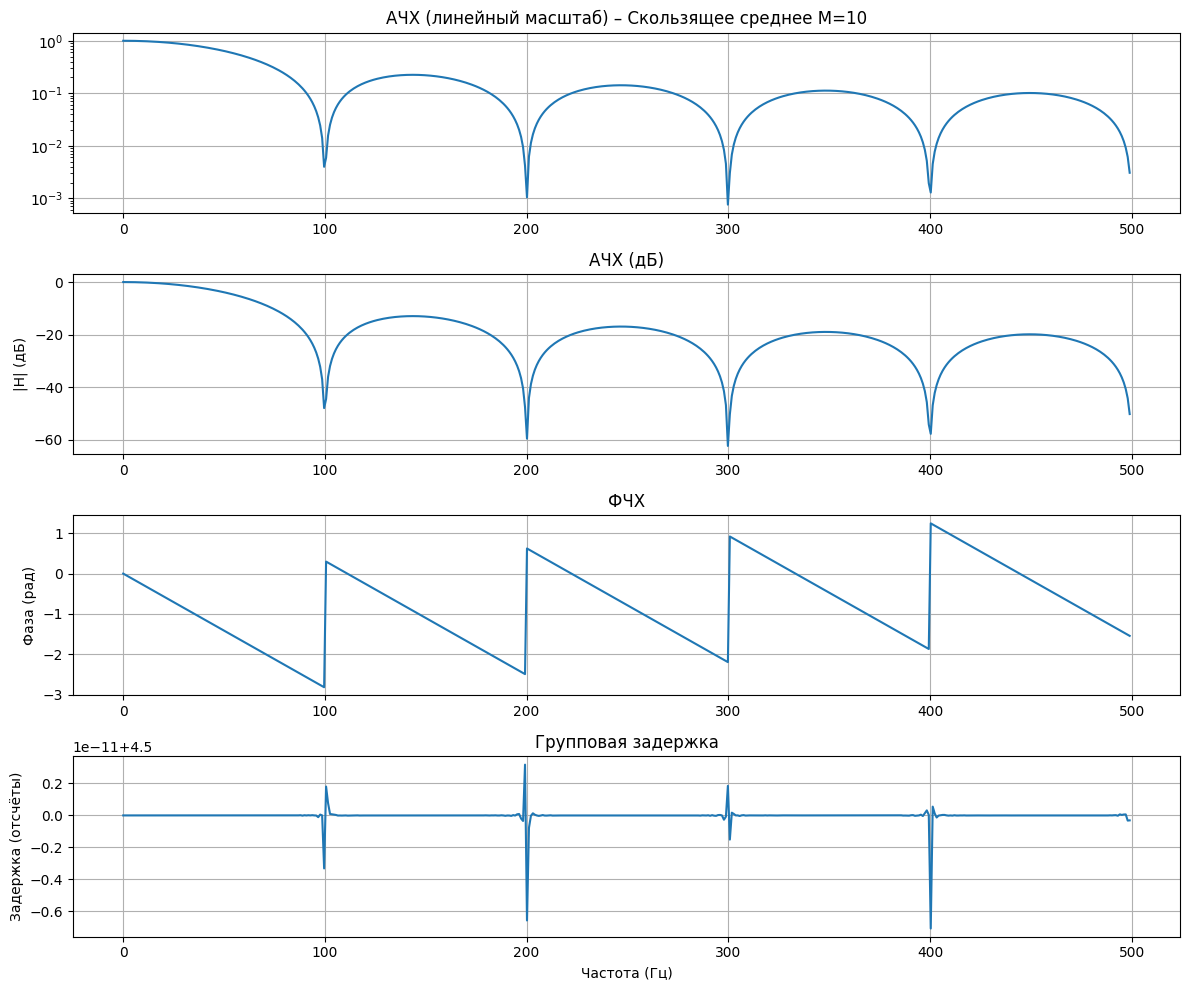

/tmp/ipykernel_14782/3306243778.py:17: UserWarning: The filter's denominator is extremely small at frequencies [1.571], around which a singularity may be present
  w_gd, gd = signal.group_delay((b, a), fs=fs)


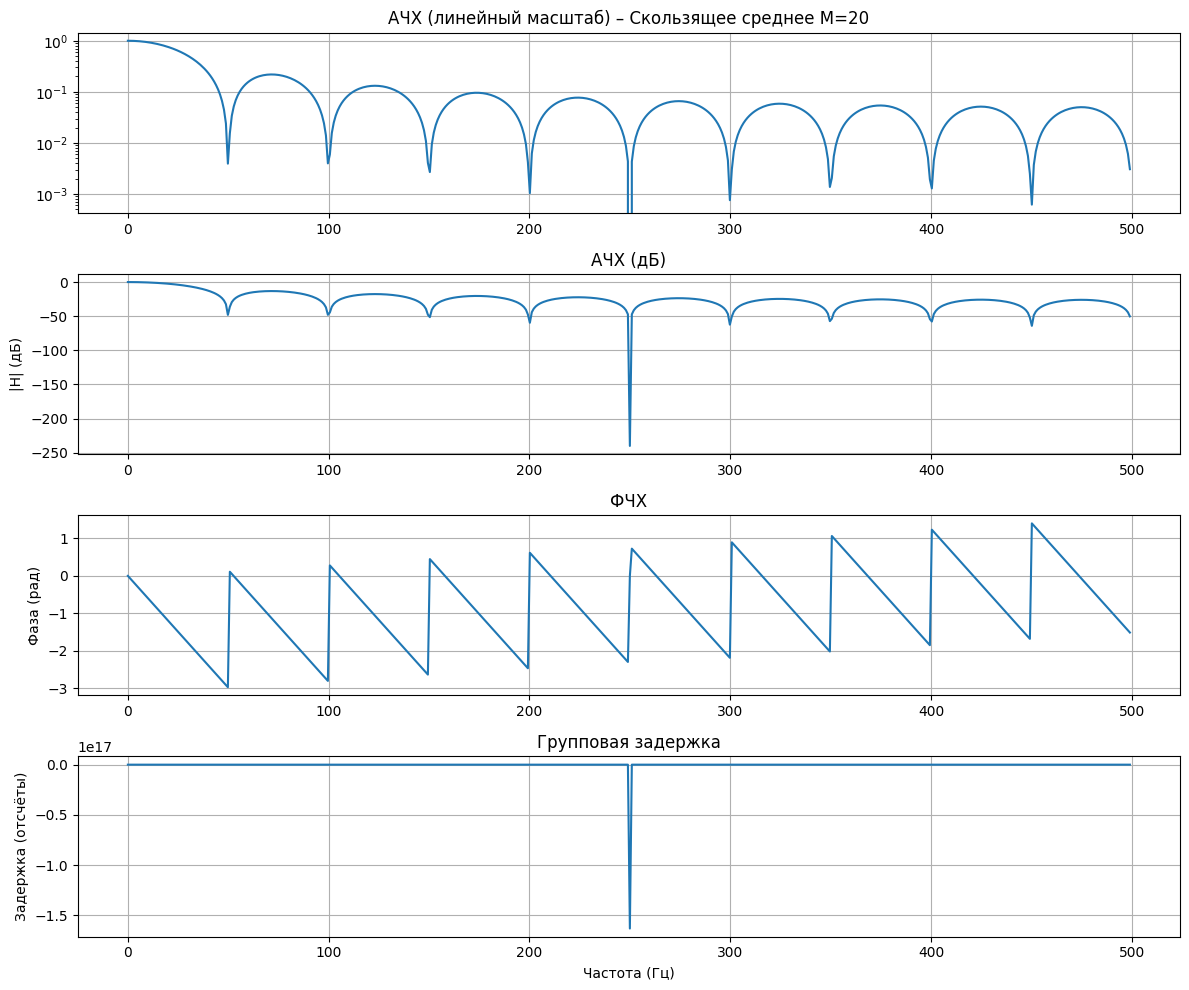

In [6]:
# Для M=5
b5 = np.ones(5) / 5
plot_filter_response(b5, [1], fs=1000, title='Скользящее среднее M=5')

# Для M=10
b10 = np.ones(10) / 10
plot_filter_response(b10, [1], fs=1000, title='Скользящее среднее M=10')

# Для M=20
b20 = np.ones(20) / 20
plot_filter_response(b20, [1], fs=1000, title='Скользящее среднее M=20')

**Вопрос:** Как изменение `M` влияет на крутизну среза АЧХ и на ФЧХ?


**Ответ:**
При увеличении M фильтр сильнее сглаживает сигнал. Полоса пропускания становится уже, а высокие частоты подавляются сильнее. То есть с ростом M фильтр становится более "жёстким" низкочастотным фильтром. ФЧХ остаётся линейной, потому что коэффициенты скользящего среднего симметричны

### Задание 1.3. Фильтрация суммы синусоид

Сгенерируйте сигнал длительностью 1 с (fs=1000 Гц): `x = sin(2π·10·t) + 0.5·sin(2π·100·t)`. Примените скользящее среднее с `M=5` и `M=20`. Постройте временные графики и спектры (амплитудный спектр через БПФ).


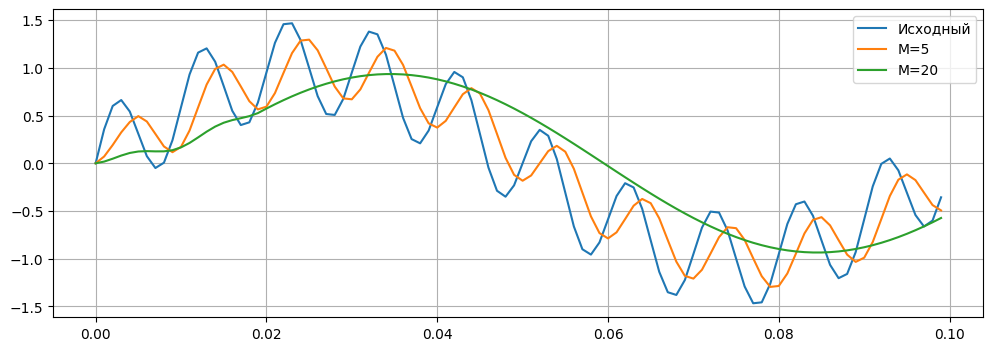

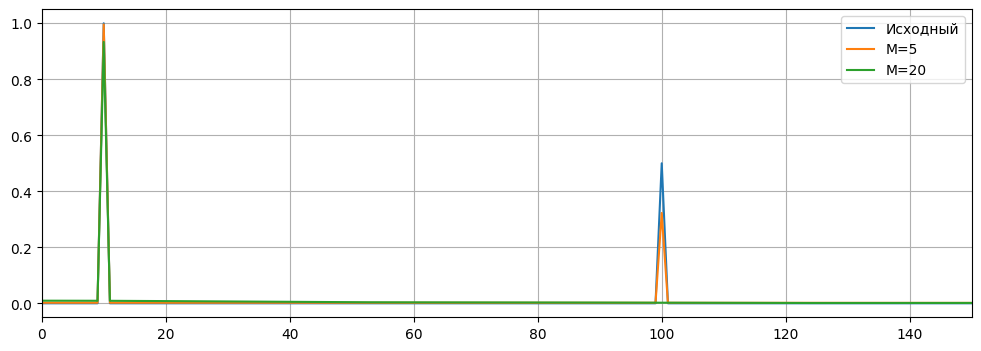

In [7]:
fs = 1000
t = np.arange(fs) / fs

x = np.sin(2*np.pi*10*t) + 0.5*np.sin(2*np.pi*100*t)

# Фильтрация с M=5
M5 = 5
b5 = np.ones(M5) / M5
y5 = signal.lfilter(b5, [1], x)

# Фильтрация с M=20
M20 = 20
b20 = np.ones(M20) / M20
y20 = signal.lfilter(b20, [1], x)

# Временные графики, первые 100 отсчётов
plt.figure(figsize=(12,4))
plt.plot(t[:100], x[:100], label='Исходный')
plt.plot(t[:100], y5[:100], label='M=5')
plt.plot(t[:100], y20[:100], label='M=20')
plt.legend()
plt.grid()
plt.show()

# Спектры
def plot_spectrum(s, label):
    X = np.fft.fft(s)
    freq = np.fft.fftfreq(len(s), 1/fs)
    plt.plot(
        freq[:len(freq)//2],
        np.abs(X[:len(freq)//2]) / (len(s)//2),
        label=label
    )

plt.figure(figsize=(12,4))
plot_spectrum(x, 'Исходный')
plot_spectrum(y5, 'M=5')
plot_spectrum(y20, 'M=20')
plt.xlim(0, 150)
plt.legend()
plt.grid()
plt.show()

**Вопрос:** Как значение `M` влияет на амплитуду 100 Гц сигнала? Объясните, почему так. Какая связь между АЧХ и результатом фильтрации?


**Ответ:**
При M=5 компонента 100 Гц подавляется не очень сильно, поэтому высокочастотная синусоида ещё заметна на графике. При M=20 компонента 100 Гц подавляется намного сильнее, поэтому сигнал становится более гладким. Это связано с АЧХ фильтра: скользящее среднее является низкочастотным фильтром. Частоты, которые попадают в область сильного ослабления АЧХ, уменьшаются по амплитуде. Поэтому по АЧХ можно заранее понять, какие частоты фильтр пропустит, а какие подавит

## Часть 2. БИХ-фильтр: экспоненциальное сглаживание

Фильтр первого порядка: `y[n] = α x[n] + (1-α) y[n-1]`. Коэффициенты: `b = [α]`, `a = [1, -(1-α)]`.

### Задание 2.1. Реализация и характеристики

Для `α = 0.2`:
1. Постройте импульсную характеристику (50 отсчётов) и переходную характеристику.
2. Используя `plot_filter_response`, постройте АЧХ, ФЧХ и групповую задержку.


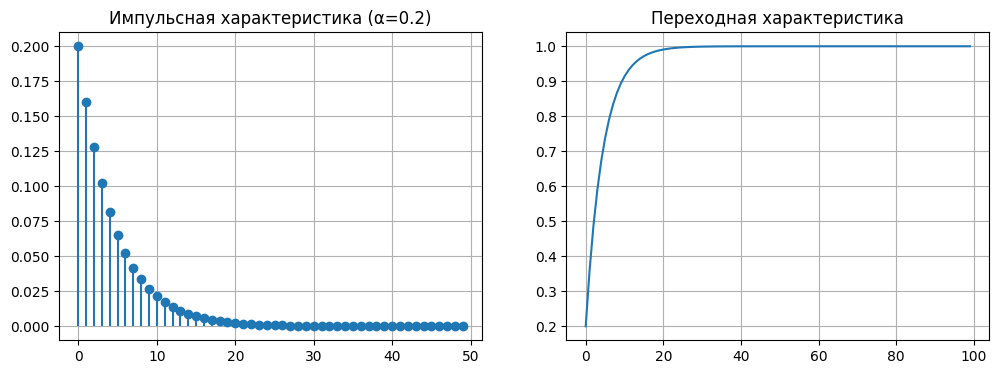

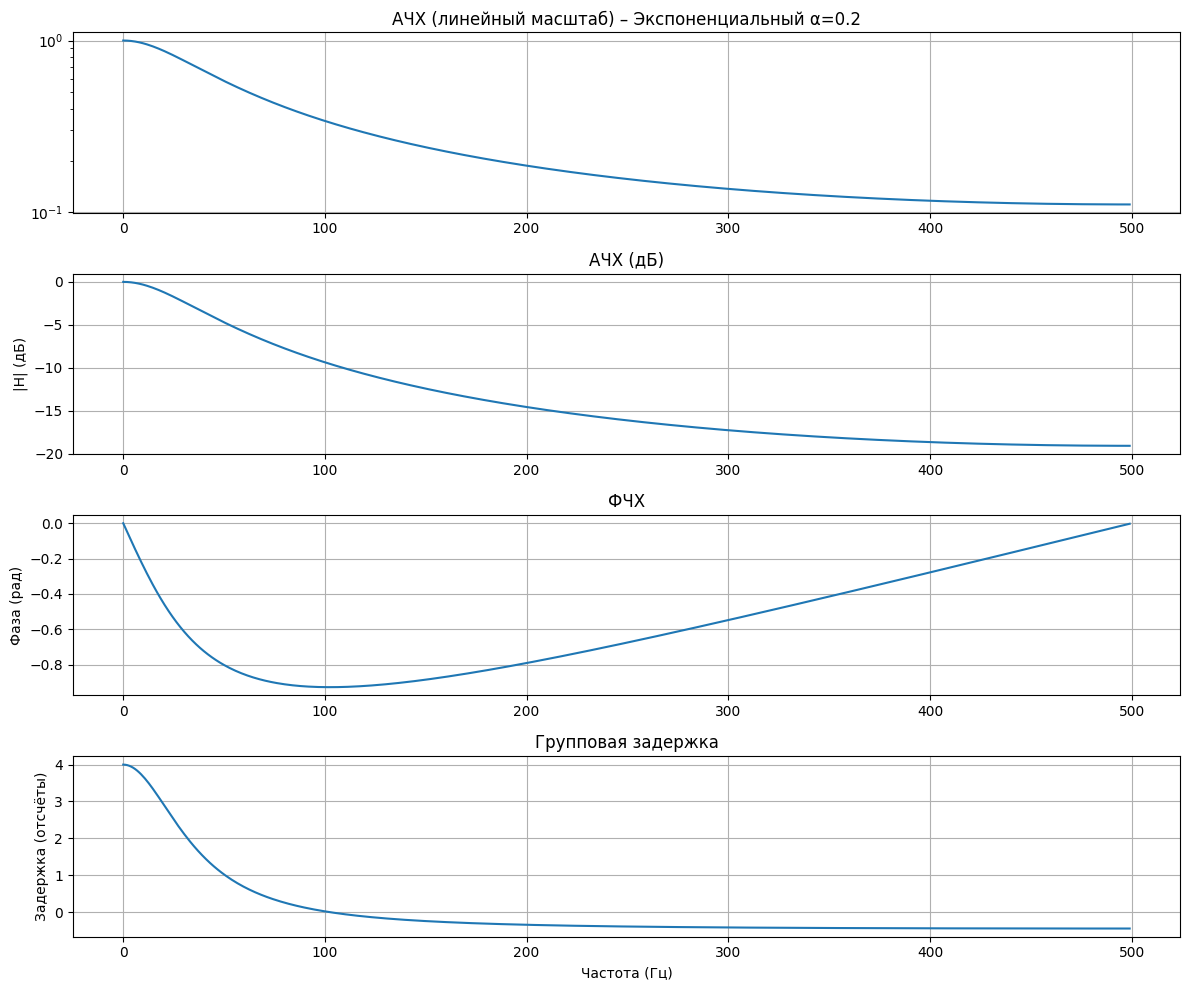

In [8]:
alpha = 0.2
b = [alpha]
a = [1, -(1-alpha)]

# Импульсная характеристика
impulse = np.zeros(50)
impulse[0] = 1
h = signal.lfilter(b, a, impulse)

# Переходная характеристика
step = np.ones(100)
s = signal.lfilter(b, a, step)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.stem(h, basefmt=" ")
plt.title(f'Импульсная характеристика (α={alpha})')
plt.grid()

plt.subplot(1,2,2)
plt.plot(s)
plt.title('Переходная характеристика')
plt.grid()

plt.show()

plot_filter_response(b, a, fs=1000, title=f'Экспоненциальный α={alpha}')

### Задание 2.2. Влияние параметра α

Исследуйте фильтр при `α = 0.05, 0.2, 0.8`. Постройте на одном графике АЧХ (в дБ) и на другом – групповую задержку. Сделайте выводы.


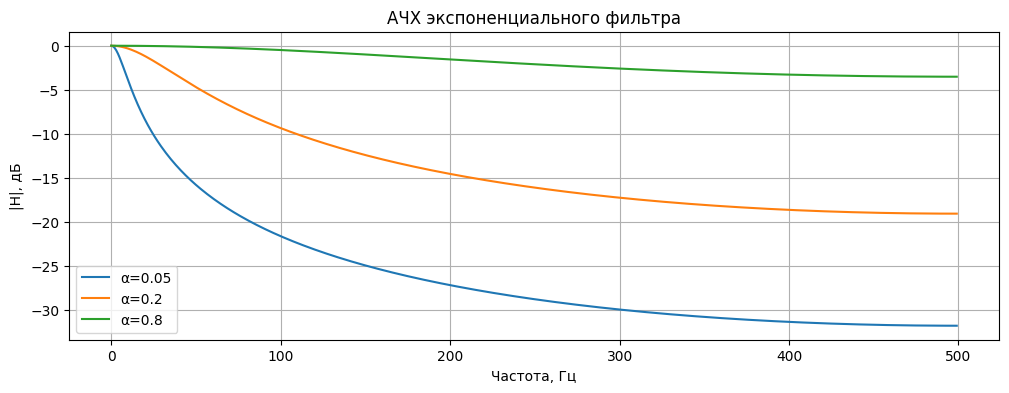

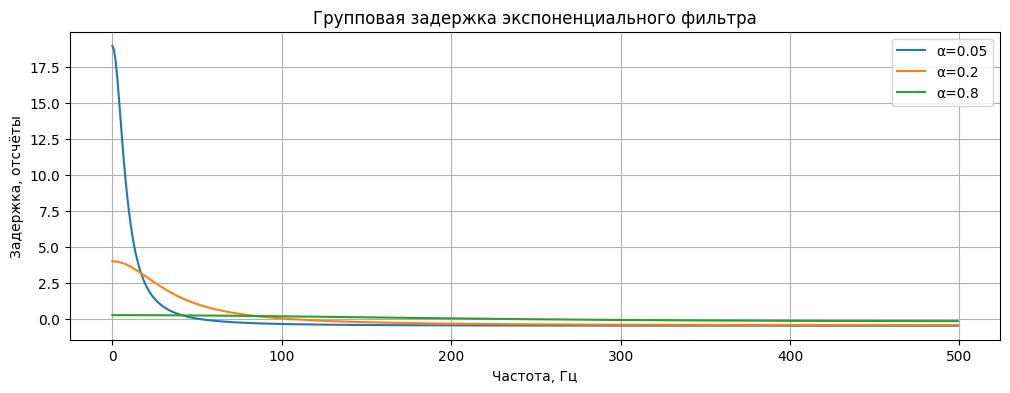

In [9]:
alphas = [0.05, 0.2, 0.8]

plt.figure(figsize=(12,4))

for alpha in alphas:
    b = [alpha]
    a = [1, -(1-alpha)]
    w, H = signal.freqz(b, a, fs=1000)
    mag_dB = 20 * np.log10(np.abs(H) + 1e-12)
    plt.plot(w, mag_dB, label=f'α={alpha}')

plt.title('АЧХ экспоненциального фильтра')
plt.xlabel('Частота, Гц')
plt.ylabel('|H|, дБ')
plt.grid()
plt.legend()
plt.show()


plt.figure(figsize=(12,4))

for alpha in alphas:
    b = [alpha]
    a = [1, -(1-alpha)]
    w_gd, gd = signal.group_delay((b, a), fs=1000)
    plt.plot(w_gd, gd, label=f'α={alpha}')

plt.title('Групповая задержка экспоненциального фильтра')
plt.xlabel('Частота, Гц')
plt.ylabel('Задержка, отсчёты')
plt.grid()
plt.legend()
plt.show()

**Вопрос:** Как α влияет на скорость реакции фильтра на изменение сигнала и на крутизну спада АЧХ?


**Ответ:**
Чем меньше α, тем сильнее фильтр сглаживает сигнал. При α = 0.05 выход меняется медленно, шум и высокие частоты подавляются сильнее, но задержка становится больше. При большом α, например α = 0.8, фильтр быстрее реагирует на изменения входного сигнала, но сглаживание становится слабее. АЧХ в этом случае имеет более широкую полосу пропускания, то есть фильтр пропускает больше высоких частот

### Задание 2.3. Фильтрация зашумлённого сигнала

Сгенерируйте сигнал: синусоида 20 Гц + белый шум (SNR ≈ 5 дБ), fs=500 Гц. Примените экспоненциальный фильтр с α = 0.1 и α = 0.5. Постройте исходный и отфильтрованные сигналы (первые 0.2 с). Сравните степень сглаживания и задержку.


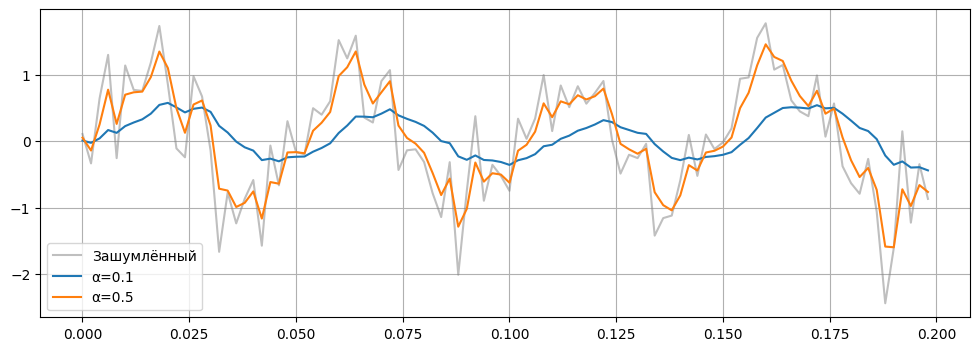

In [10]:
fs = 500
t = np.arange(fs) / fs

x_clean = np.sin(2*np.pi*20*t)
noise = 0.5 * np.random.randn(len(t))
x_noisy = x_clean + noise

# Фильтрация с alpha=0.1
alpha1 = 0.1
y01 = signal.lfilter([alpha1], [1, -(1-alpha1)], x_noisy)

# Фильтрация с alpha=0.5
alpha2 = 0.5
y05 = signal.lfilter([alpha2], [1, -(1-alpha2)], x_noisy)

plt.figure(figsize=(12,4))
plt.plot(t[:100], x_noisy[:100], 'gray', alpha=0.5, label='Зашумлённый')
plt.plot(t[:100], y01[:100], label='α=0.1')
plt.plot(t[:100], y05[:100], label='α=0.5')
plt.legend()
plt.grid()
plt.show()

**Вопрос:** Как на временных графиках проявляется групповая задержка, вносимая БИХ-фильтром?


**Ответ:**
На временных графиках групповая задержка проявляется как сдвиг отфильтрованного сигнала вправо относительно исходного. Пики и переходы появляются немного позже. При α = 0.1 задержка заметнее, потому что фильтр сильнее учитывает прошлые значения и медленнее реагирует на изменения. При α = 0.5 задержка меньше, но шум подавляется слабее

## Часть 3. Фильтр Савицкого – Голея (Savitzky–Golay)

Этот КИХ-фильтр основан на локальной полиномиальной регрессии. Он сохраняет форму сигнала (пики, перегибы) лучше, чем скользящее среднее.

### Задание 3.1. Базовое применение и влияние параметров

Сгенерируйте синусоиду 5 Гц (fs=100 Гц, длительность 2 с) и добавьте белый шум (дисперсия 0.2). Примените `savgol_filter` с параметрами:
- (window=11, polyorder=2)
- (window=21, polyorder=2)
- (window=11, polyorder=5)

Постройте исходный чистый сигнал, зашумлённый и три сглаженные версии. Объясните влияние параметров.


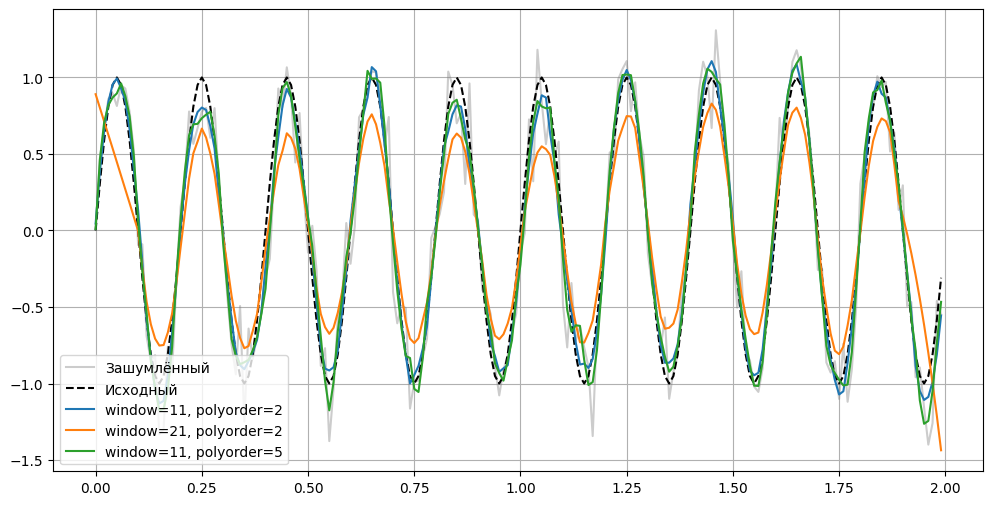

In [11]:
fs = 100
t = np.arange(2*fs) / fs

x_clean = np.sin(2*np.pi*5*t)
noise = 0.2 * np.random.randn(len(t))
x_noisy = x_clean + noise

# Savitzky-Golay с разными параметрами
y1 = savgol_filter(x_noisy, window_length=11, polyorder=2)
y2 = savgol_filter(x_noisy, window_length=21, polyorder=2)
y3 = savgol_filter(x_noisy, window_length=11, polyorder=5)

plt.figure(figsize=(12,6))
plt.plot(t, x_noisy, 'gray', alpha=0.4, label='Зашумлённый')
plt.plot(t, x_clean, 'k--', label='Исходный')
plt.plot(t, y1, label='window=11, polyorder=2')
plt.plot(t, y2, label='window=21, polyorder=2')
plt.plot(t, y3, label='window=11, polyorder=5')
plt.legend()
plt.grid()
plt.show()

**Вопрос 3.1:** Как увеличение `window_length` и увеличение `polyorder` влияют на степень сглаживания и сохранение формы сигнала?


**Ответ:**
Увеличение window_length усиливает сглаживание, потому что фильтр использует больше соседних точек. Поэтому шум уменьшается сильнее, но при слишком большом окне могут сглаживаться важные детали сигнала. Увеличение polyorder позволяет фильтру лучше повторять форму сигнала, например изгибы и пики. Но если порядок полинома слишком высокий, фильтр может начать хуже подавлять шум, потому что будет сильнее подстраиваться под случайные колебания. В данном случае window=21, polyorder=2 сглаживает сильнее, чем window=11, polyorder=2, а window=11, polyorder=5 лучше сохраняет форму, но может пропускать больше шума

### Задание 3.2. Сравнение со скользящим средним

Создайте сигнал с острым пиком (гауссов импульс с σ=3) на фоне шума. Примените скользящее среднее (window=11) и Savitzky–Golay (window=11, polyorder=2). Сравните, какой фильтр лучше сохраняет форму пика.


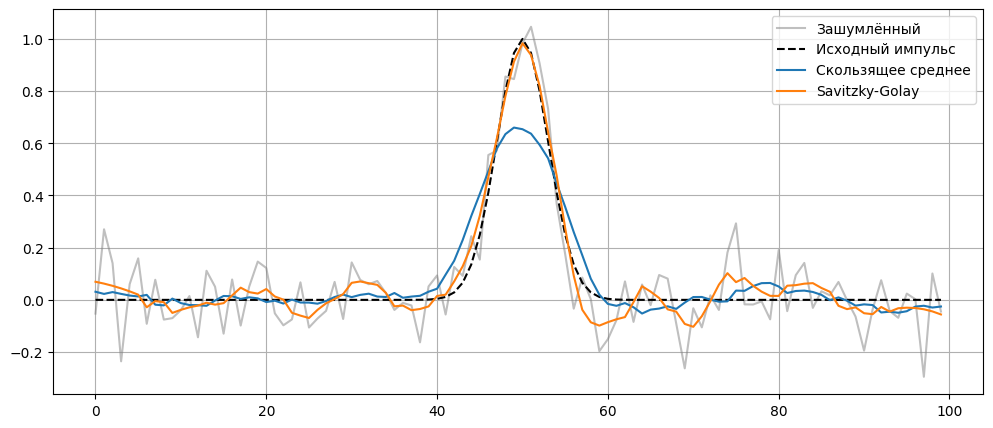

In [12]:
# Генерация гауссова импульса
N = 100
x_pulse = np.zeros(N)
x_pulse[N//2] = 1

sigma = 3
gaussian = np.exp(-(np.arange(N)-N//2)**2 / (2*sigma**2))
x_clean_pulse = gaussian / np.max(gaussian)

noise_pulse = 0.1 * np.random.randn(N)
x_noisy_pulse = x_clean_pulse + noise_pulse

# Скользящее среднее window=11
window = 11
b_ma = np.ones(window) / window
y_ma = np.convolve(x_noisy_pulse, b_ma, mode='same')

# Savitzky-Golay window=11, polyorder=2
y_sg = savgol_filter(x_noisy_pulse, window_length=11, polyorder=2)

plt.figure(figsize=(12,5))
plt.plot(x_noisy_pulse, 'gray', alpha=0.5, label='Зашумлённый')
plt.plot(x_clean_pulse, 'k--', label='Исходный импульс')
plt.plot(y_ma, label='Скользящее среднее')
plt.plot(y_sg, label='Savitzky-Golay')
plt.legend()
plt.grid()
plt.show()

**Вопрос:** Какой из фильтров лучше сохраняет пик?


**Ответ:**
Фильтр Savitzky–Golay лучше сохраняет пик. Скользящее среднее сильнее размывает пик и уменьшает его максимальную амплитуду, потому что просто усредняет значения в окне. Savitzky–Golay внутри окна приближает сигнал полиномом, поэтому он лучше сохраняет локальную форму сигнала, включая пики и изгибы

### Задание 3.3. Частотные характеристики

Получите коэффициенты Savitzky–Golay для `window_length=11, polyorder=2` с помощью `savgol_coeffs`. Нормируйте их так, чтобы сумма была равна 1. Постройте АЧХ этого фильтра и сравните с АЧХ скользящего среднего той же длины.


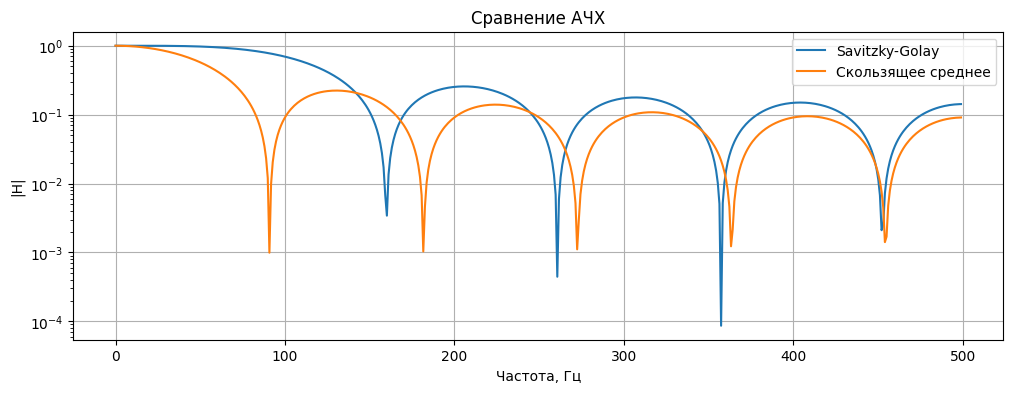

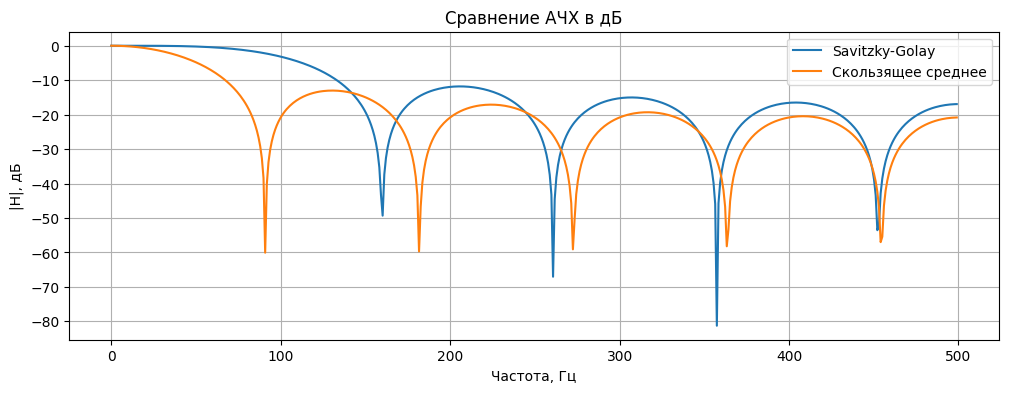

In [13]:
window_length = 11
polyorder = 2

coeffs = savgol_coeffs(window_length, polyorder)
coeffs = coeffs / np.sum(coeffs)

# Скользящее среднее той же длины
b_ma = np.ones(window_length) / window_length

# АЧХ
w_sg, H_sg = signal.freqz(coeffs, [1], fs=1000)
w_ma, H_ma = signal.freqz(b_ma, [1], fs=1000)

plt.figure(figsize=(12,4))
plt.semilogy(w_sg, np.abs(H_sg), label='Savitzky-Golay')
plt.semilogy(w_ma, np.abs(H_ma), label='Скользящее среднее')
plt.title('Сравнение АЧХ')
plt.xlabel('Частота, Гц')
plt.ylabel('|H|')
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(w_sg, 20*np.log10(np.abs(H_sg) + 1e-12), label='Savitzky-Golay')
plt.plot(w_ma, 20*np.log10(np.abs(H_ma) + 1e-12), label='Скользящее среднее')
plt.title('Сравнение АЧХ в дБ')
plt.xlabel('Частота, Гц')
plt.ylabel('|H|, дБ')
plt.grid()
plt.legend()
plt.show()

**Вопрос:** Чем отличается АЧХ Savitzky–Golay от АЧХ скользящего среднего? Как это объясняет сохранение формы сигнала?


**Ответ:**
АЧХ Savitzky–Golay более ровная в области низких частот, поэтому он меньше искажает медленно меняющиеся компоненты сигнала. Скользящее среднее сильнее подавляет часть частот, но из-за этого может сильнее искажать форму сигнала. Это объясняет, почему Savitzky–Golay лучше сохраняет форму пиков и изгибов: он не просто усредняет сигнал, а локально аппроксимирует его полиномом

### Задание 3.4. Фильтрация меандра

Сгенерируйте меандр частотой 2 Гц (fs=500 Гц) и добавьте синусоидальную помеху 50 Гц амплитудой 0.5. Примените Savitzky–Golay (window=15, polyorder=3) и скользящее среднее (window=15). Сравните, как подавляется помеха и сохраняются фронты.


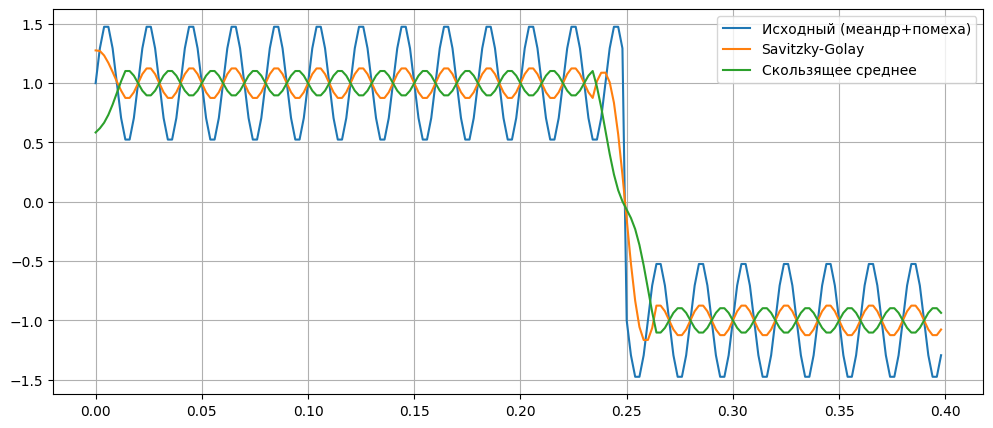

In [14]:
fs = 500
t = np.arange(fs) / fs

meander = signal.square(2*np.pi*2*t)
interference = 0.5 * np.sin(2*np.pi*50*t)
x_meander = meander + interference

# Savitzky-Golay
y_sg = savgol_filter(x_meander, window_length=15, polyorder=3)

# Скользящее среднее
window = 15
b_ma = np.ones(window) / window
y_ma = np.convolve(x_meander, b_ma, mode='same')

plt.figure(figsize=(12,5))
plt.plot(t[:200], x_meander[:200], label='Исходный (меандр+помеха)')
plt.plot(t[:200], y_sg[:200], label='Savitzky-Golay')
plt.plot(t[:200], y_ma[:200], label='Скользящее среднее')
plt.legend()
plt.grid()
plt.show()

**Вопрос:** Какой фильтр лучше подходит для обработки сигналов с резкими фронтами? Почему?


**Ответ:**
Для сигналов с резкими фронтами лучше подходит Savitzky–Golay. Он лучше сохраняет форму переходов и меньше размывает фронты. Скользящее среднее тоже подавляет помеху, но оно заметнее сглаживает резкие переходы, поэтому фронты становятся более пологими. Savitzky–Golay обычно оставляет фронты более резкими, хотя часть высокочастотной помехи может подавляться чуть слабее

## Часть 4. Сравнение КИХ и БИХ фильтров

Для скользящего среднего (`M=10`), экспоненциального фильтра (`α=0.2`) и Savitzky–Golay (`win=11, polyorder=2`):

1. Постройте на одном графике их АЧХ (в дБ) и групповую задержку.
2. Подайте на них единичный импульс и единичный скачок, постройте реакции.
3. Сгенерируйте сигнал из прямоугольных импульсов с шумом (как в примере ниже) и примените все три фильтра. Оцените качество подавления шума и сохранения фронтов.


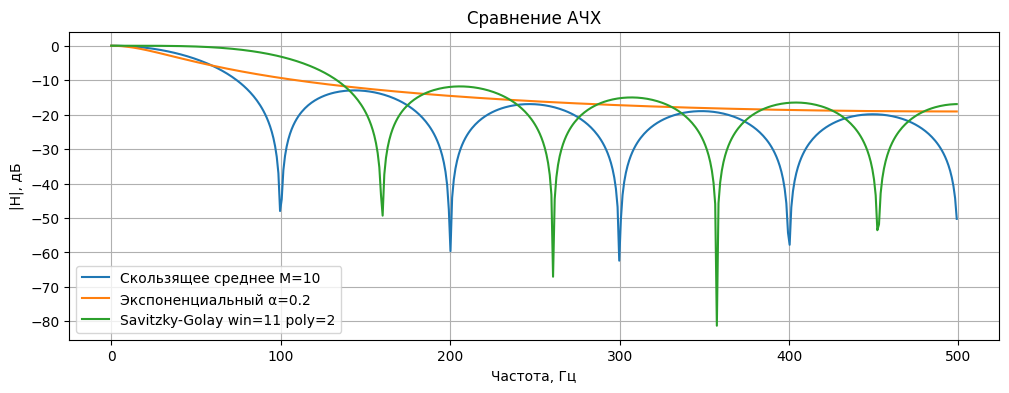

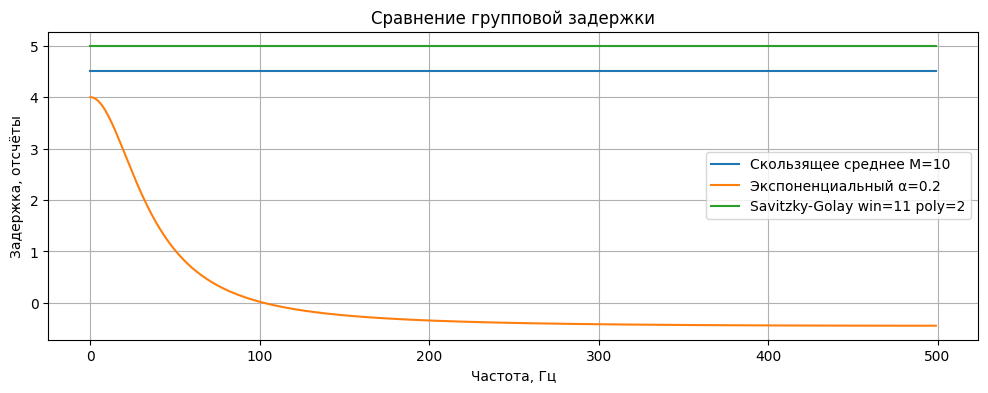

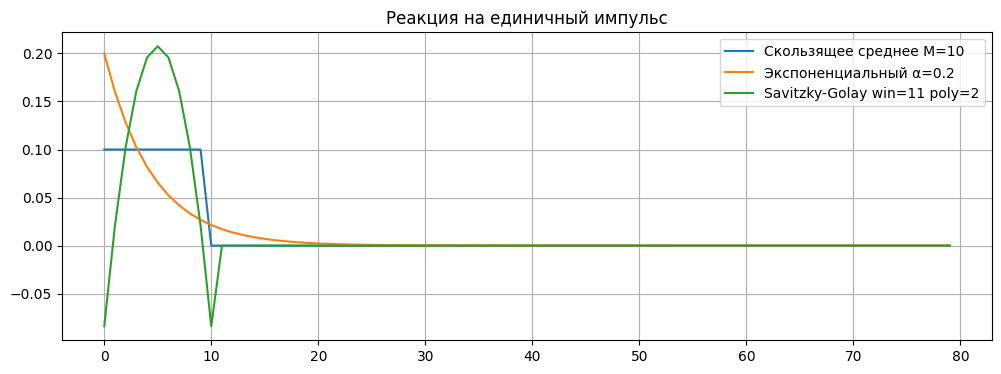

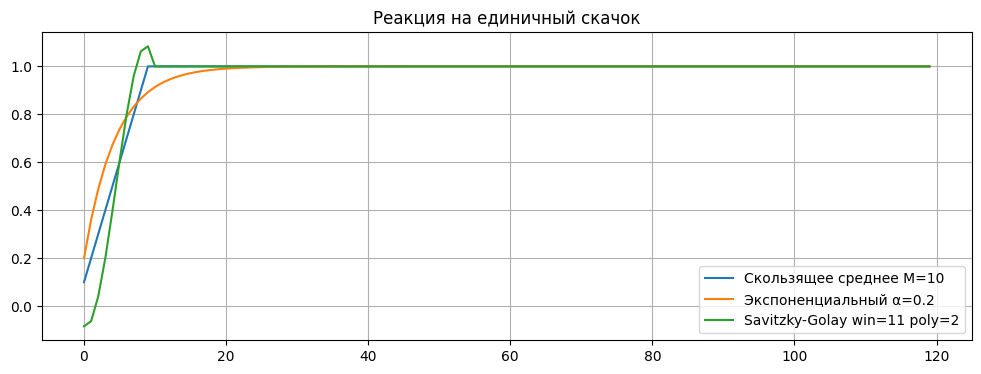

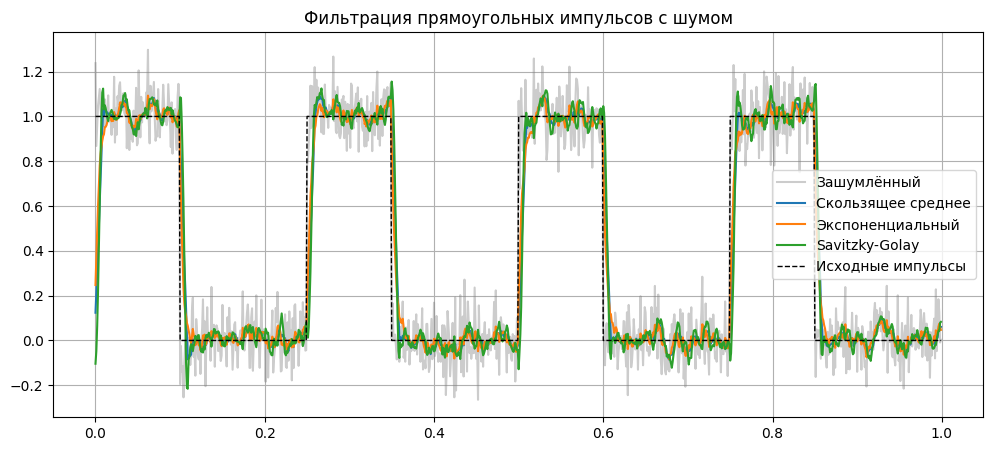

In [15]:
# Сигнал с прямоугольными импульсами
fs = 1000
t = np.arange(fs) / fs

pulse_train = np.zeros_like(t)
pulse_train[0:100] = 1
pulse_train[250:350] = 1
pulse_train[500:600] = 1
pulse_train[750:850] = 1

noise = 0.1 * np.random.randn(len(t))
x_pulse_noisy = pulse_train + noise

# Коэффициенты фильтров

# 1. Скользящее среднее M=10
M = 10
b_ma = np.ones(M) / M
a_ma = [1]

# 2. Экспоненциальный фильтр alpha=0.2
alpha = 0.2
b_exp = [alpha]
a_exp = [1, -(1-alpha)]

# 3. Savitzky-Golay win=11, polyorder=2
b_sg = savgol_coeffs(11, 2)
b_sg = b_sg / np.sum(b_sg)
a_sg = [1]

filters = [
    ('Скользящее среднее M=10', b_ma, a_ma),
    ('Экспоненциальный α=0.2', b_exp, a_exp),
    ('Savitzky-Golay win=11 poly=2', b_sg, a_sg)
]

# 1. АЧХ в дБ
plt.figure(figsize=(12,4))

for name, b, a in filters:
    w, H = signal.freqz(b, a, fs=fs)
    plt.plot(w, 20*np.log10(np.abs(H) + 1e-12), label=name)

plt.title('Сравнение АЧХ')
plt.xlabel('Частота, Гц')
plt.ylabel('|H|, дБ')
plt.grid()
plt.legend()
plt.show()


# 2. Групповая задержка
plt.figure(figsize=(12,4))

for name, b, a in filters:
    w_gd, gd = signal.group_delay((b, a), fs=fs)
    plt.plot(w_gd, gd, label=name)

plt.title('Сравнение групповой задержки')
plt.xlabel('Частота, Гц')
plt.ylabel('Задержка, отсчёты')
plt.grid()
plt.legend()
plt.show()


# 3. Реакция на импульс
impulse = np.zeros(80)
impulse[0] = 1

plt.figure(figsize=(12,4))

for name, b, a in filters:
    h = signal.lfilter(b, a, impulse)
    plt.plot(h, label=name)

plt.title('Реакция на единичный импульс')
plt.grid()
plt.legend()
plt.show()


# 4. Реакция на скачок
step = np.ones(120)

plt.figure(figsize=(12,4))

for name, b, a in filters:
    s = signal.lfilter(b, a, step)
    plt.plot(s, label=name)

plt.title('Реакция на единичный скачок')
plt.grid()
plt.legend()
plt.show()


# 5. Фильтрация сигнала с прямоугольными импульсами
y_ma = signal.lfilter(b_ma, a_ma, x_pulse_noisy)
y_exp = signal.lfilter(b_exp, a_exp, x_pulse_noisy)
y_sg = signal.lfilter(b_sg, a_sg, x_pulse_noisy)

plt.figure(figsize=(12,5))
plt.plot(t, x_pulse_noisy, 'gray', alpha=0.4, label='Зашумлённый')
plt.plot(t, y_ma, label='Скользящее среднее')
plt.plot(t, y_exp, label='Экспоненциальный')
plt.plot(t, y_sg, label='Savitzky-Golay')
plt.plot(t, pulse_train, 'k--', linewidth=1, label='Исходные импульсы')
plt.title('Фильтрация прямоугольных импульсов с шумом')
plt.grid()
plt.legend()
plt.show()

**Вопрос:** Какой фильтр обеспечивает наилучшее подавление шума? Какой лучше сохраняет фронты? Какой имеет наименьшие фазовые искажения?


**Ответ:**
Лучшее подавление шума: скользящее среднее / экспоненциальный фильтр.
Лучшее сохранение фронтов: Savitzky-Golay.
Наименьшие фазовые искажения: скользящее среднее и Savitzky-Golay.
Самая заметная нелинейная фазовая задержка: экспоненциальный БИХ-фильтр.